---
title: "Practice Activity 6-1: Writing Functions"
author: "Shiqi Wu"
format:
  html:
    embed-resources: true
    code-overflow: wrap
    include-in-header:
      text: |
        <style>
        .cell-output-display figure {
          width: 100%;
          max-width: 100%;
        }
        .cell-output-display img {
          max-width: 100% !important;
          height: auto !important;
        }
        </style>
execute:
  enabled: false
---

In [32]:
%pip install "setuptools<81" palmerpenguins

Note: you may need to restart the kernel to use updated packages.


In [33]:
import numpy as np
import pandas as pd
from sys import exit
from palmerpenguins import load_penguins
from plotnine import ggplot, aes, geom_point, geom_bar

0\. Complete the [**check-in** from Section 6.3.2](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html#nested-environments-and-scope): Write a custom function that does the following:

Limit the penguins dataset to a user-chosen species and/or island.
Makes a scatterplot of the penguin bill length and depth.
Try writing a version of this function using dynamic lookup, and a version where everything the function needs is passed in directly

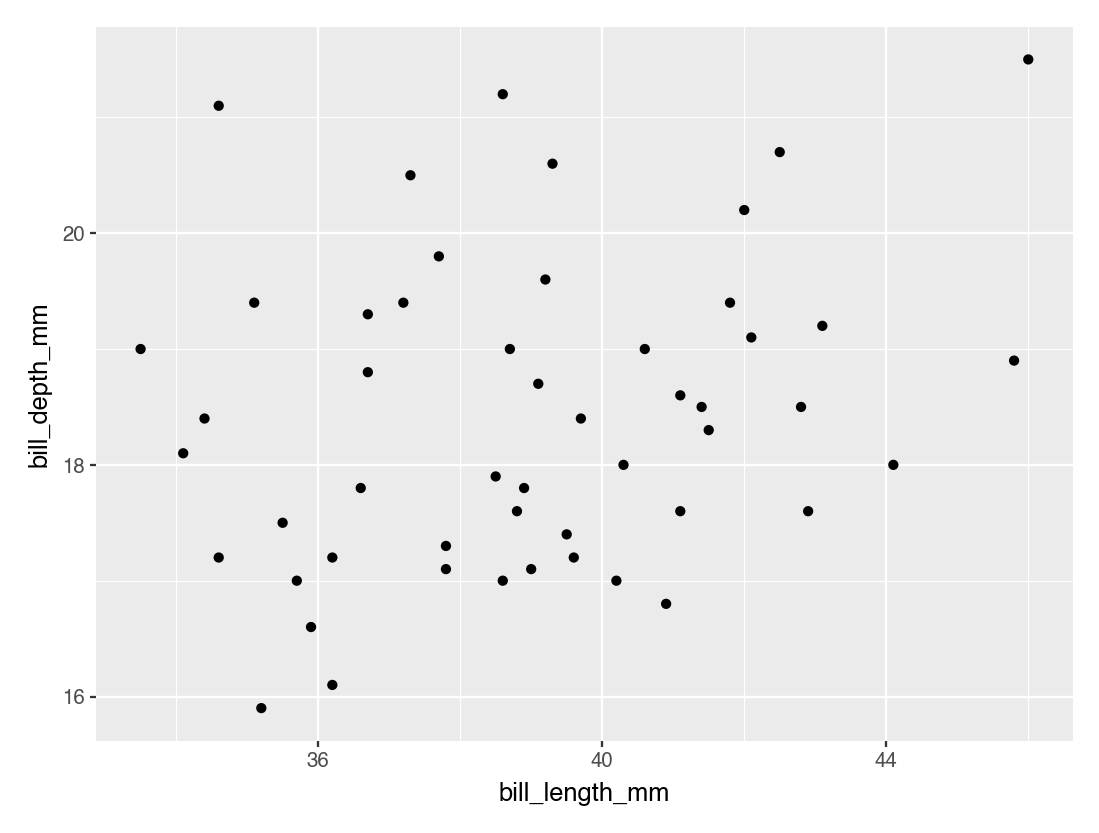

In [34]:
penguins = load_penguins()

def plot_penguins(species=None, island=None):
    data = penguins

    if species is not None:
        data = data[data["species"] == species]

    if island is not None:
        data = data[data["island"] == island]

    data = data.dropna(subset=["bill_length_mm", "bill_depth_mm"])

    return (
        ggplot(data, aes(x="bill_length_mm", y="bill_depth_mm"))
        + geom_point()
    )

plot_penguins(species="Adelie", island="Torgersen")

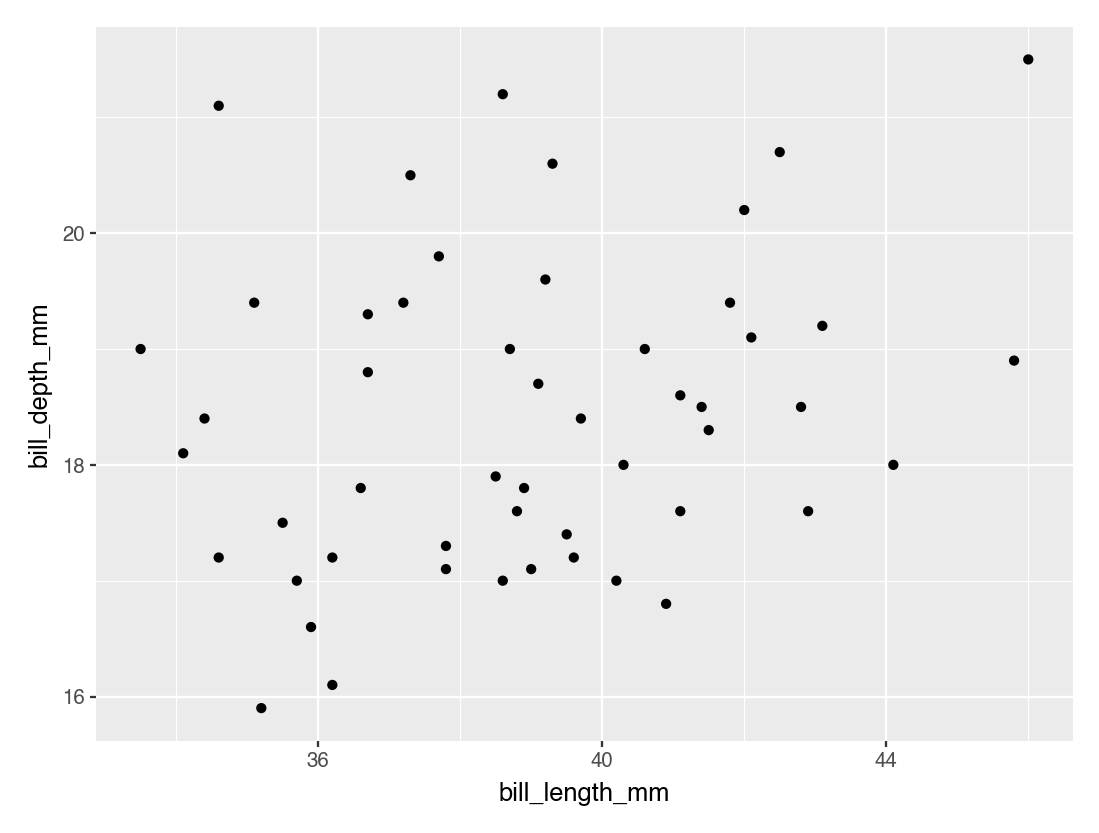

In [35]:
def plot_penguins_direct(data, species=None, island=None):
    if species is not None:
        data = data[data["species"] == species]

    if island is not None:
        data = data[data["island"] == island]

    data = data.dropna(subset=["bill_length_mm", "bill_depth_mm"])

    return (
        ggplot(data, aes(x="bill_length_mm", y="bill_depth_mm"))
        + geom_point()
    )

plot_penguins_direct(
    penguins,
    species="Adelie",
    island="Torgersen"
)

1. Fill in the necessary code to write a function called `times_seven()`. The function should take a single argument (`x`) and multiply the input by 7.
  + This function should check that the argument is numeric.
  + This function should also excitedly announce (print) *“I love sevens!”* if the argument to the function is a 7.

In [36]:
def times_seven(x):
    if not isinstance(x, (int, float)):
        exit("Please enter a numeric value.")

    if x == 7:
        print("I love sevens!")

    return x * 7

2. Write and run some *unit tests* for your `times_seven` function.  What happens if the input to the function is `[1, 3, 5, 7]`?

In [37]:
assert times_seven(3) == 21
assert times_seven(2.5) == 17.5
assert times_seven(0) == 0
assert times_seven(-2) == -14
assert times_seven(7) == 49

print("All numeric tests passed.")

try:
    times_seven([1, 3, 5, 7])
except SystemExit as error:
    print("List input:", error)

I love sevens!
All numeric tests passed.
List input: Please enter a numeric value.


Answer: The function passed tests with a positive integer, a decimal, zero, a negative number, and 7. When the input is 7, it prints "I love sevens!" and returns 49.

Also, the input [1, 3, 5, 7] is a list, not a single integer or float, so it fails the numeric check. The function calls exit() with the message "Please enter a numeric value." It does not multiply each element by 7. The test catches SystemExit so the message can be displayed without interrupting the notebook.

3. Consider the following function:

In [38]:
def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

    return res

**Without running the code**, predict if the following will produce:

a. 1

b. -1

c. 30

d. An error defined by the function `add_or_subtract()`

e. An error defined in a different function, which is called inside the `add_or_subtract()` function

In [ ]:
add_or_subtract(5, 6, type = "subtract")

add_or_subtract("orange")

add_or_subtract(5, 6, type = "multiply")

Answer:

1. `add_or_subtract(5, 6, type="subtract")` returns `None`. It calculates `res = -1`, but `return res` is inside the `else` block, so the subtraction branch does not return the result. None of the listed options describes this result.

2. `add_or_subtract("orange")` raises a `TypeError` because it tries to add the string `"orange"` to the default integer `2`. This corresponds to option e: Python's addition operation raises the error.

3. If called separately, `add_or_subtract(5, 6, type="multiply")` raises `SystemExit` with the message "Please choose `add` or `subtract` as the type." This corresponds to option d, the function's custom error condition.

The `return res` statement cannot be reached because it is inside the `else` block after `exit()`. If all three calls run in one code cell, the second call raises an error and prevents the third call from running.

4. Consider the following code:

In [42]:
first_num  = 5
second_num = 3

result = 8

result = add_or_subtract(first_num, second_num = 4)

result_2 = add_or_subtract(first_num)


In your Global Environment, what is the value of...

a. `first_num`

b. `second_num`

c. `result`

d. `result_2`

Answer:

a. `first_num` is `5`.

b. `second_num` is `3`.

c. `result` is `None`.

d. `result_2` is `None`.

Passing `second_num=4` to the function does not change the global variable `second_num`, so it stays `3`.

Both function calls return `None` because `return res` is inside the `else` block and is not reached. The first call replaces the original value of `result`, which was `8`, with `None`. The second call also returns `None`, so `result_2` is `None`.